# 🏠 DỰ ĐOÁN GIÁ NHÀ TẠI VIỆT NAM

## Môn học: Phát triển các hệ thống thông minh

### Mục tiêu

Xây dựng mô hình Machine Learning dự đoán giá nhà dựa trên
Vietnam Housing Dataset 2024.

Quy trình thực hiện:

1. Load và khám phá dataset.
2. Phân tích dữ liệu bằng 3 biểu đồ phân phối.
3. Tiền xử lý dữ liệu.
4. Xây dựng 5 mô hình Regression.
5. Đánh giá 5 mô hình bằng 5 độ đo.
6. Lựa chọn mô hình tốt nhất.
7. Lưu mô hình để triển khai trên Web.

### Bài toán

Đây là bài toán Regression.

- Input: Các đặc điểm của bất động sản.
- Output: Giá nhà (`Price`).

## 1. Import thư viện

Sử dụng Pandas và NumPy để xử lý dữ liệu, Matplotlib và Seaborn
để trực quan hóa, đồng thời sử dụng Scikit-learn để xây dựng,
huấn luyện và đánh giá các mô hình Machine Learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

Dataset sử dụng là Vietnam Housing Dataset 2024.

Dữ liệu chứa các thông tin về bất động sản như diện tích,
mặt tiền, đường vào, hướng nhà, số tầng, số phòng ngủ,
số phòng tắm, pháp lý, nội thất và giá nhà.

In [2]:
# Đường dẫn đến dataset
file_path = "../data/houseprice.csv"

# Đọc dữ liệu
df = pd.read_csv(file_path)

print("Kích thước dataset:", df.shape)

df.head()

Kích thước dataset: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [3]:
print(df.columns.tolist())

['Address', 'Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price']


## 3. Khám phá và kiểm tra dữ liệu

Trước khi xây dựng mô hình, cần kiểm tra:

- Số lượng mẫu và thuộc tính.
- Kiểu dữ liệu.
- Giá trị bị thiếu.
- Dữ liệu trùng lặp.

Dataset thực tế có thể không đầy đủ thông tin ở tất cả các thuộc tính,
do đó các giá trị thiếu sẽ được xử lý bằng Pipeline ở bước tiền xử lý.

In [4]:
# Thông tin dataset
df.info()

# Thống kê dữ liệu thiếu
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

missing[missing["Missing"] > 0]

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 5.4 MB


,Missing,Percentage
Frontage,11564,38.25
Access Road,13297,43.99
House direction,21239,70.26
Balcony direction,24983,82.65
Floors,3603,11.92
Bedrooms,5162,17.08
Bathrooms,7074,23.40
Legal status,4506,14.91
Furniture state,14119,46.71


## 4. Làm sạch dữ liệu

Các dòng trùng lặp được loại bỏ.

Đối với biến mục tiêu `Price`, những dòng không có giá bán
không thể sử dụng để huấn luyện nên sẽ được loại bỏ.

Các giá trị thiếu ở những thuộc tính đầu vào sẽ không bị xóa,
mà được xử lý bằng phương pháp Imputation trong Pipeline.

In [5]:
# Xóa dữ liệu trùng lặp
df = df.drop_duplicates().reset_index(drop=True)

# Đảm bảo Price là kiểu số
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Loại bỏ các dòng không có Price
df = df.dropna(subset=["Price"]).reset_index(drop=True)

# Loại bỏ Price không hợp lệ
df = df[df["Price"] > 0].reset_index(drop=True)

print("Kích thước dữ liệu sau xử lý:", df.shape)

Kích thước dữ liệu sau xử lý: (30229, 12)


## 5.1. Biểu đồ phân phối giá nhà

Biểu đồ histogram kết hợp KDE được sử dụng để quan sát
sự phân bố của giá nhà trong dataset.

Biểu đồ giúp nhận biết khoảng giá phổ biến và sự phân bố
của biến mục tiêu `Price`.

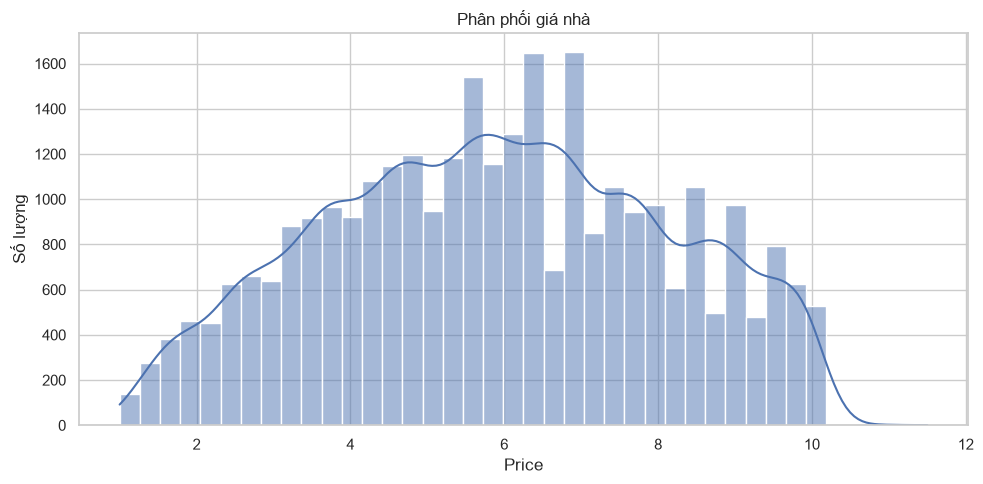

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Price",
    kde=True,
    bins=40
)

plt.title("Phân phối giá nhà")
plt.xlabel("Price")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()

## 5.2. Biểu đồ phân phối diện tích

`Area` là một thuộc tính quan trọng của bất động sản.

Biểu đồ cho thấy sự phân bố diện tích của các căn nhà
trong dataset.

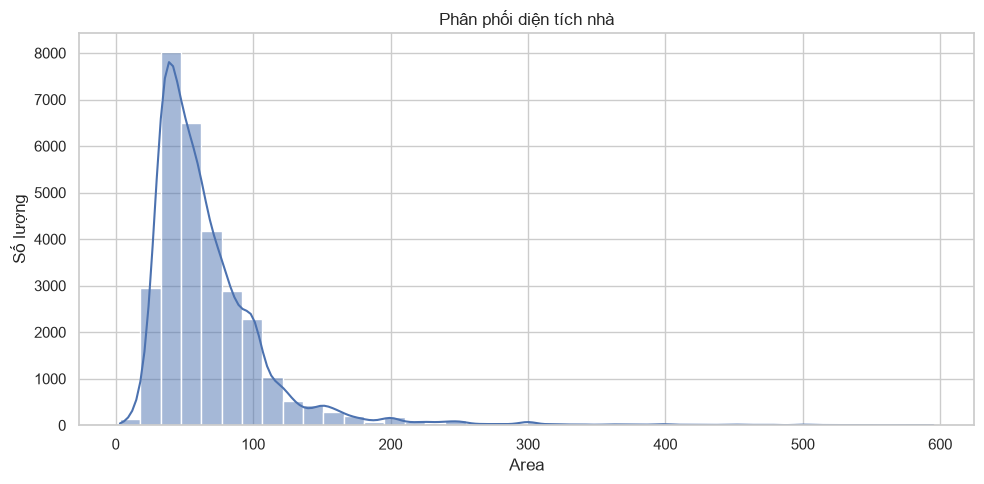

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Area",
    kde=True,
    bins=40
)

plt.title("Phân phối diện tích nhà")
plt.xlabel("Area")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()

## 5.3. Biểu đồ phân phối số phòng ngủ

Biểu đồ thể hiện số lượng bất động sản theo số phòng ngủ.
Do `Bedrooms` là biến rời rạc, sử dụng countplot để trực quan hóa.

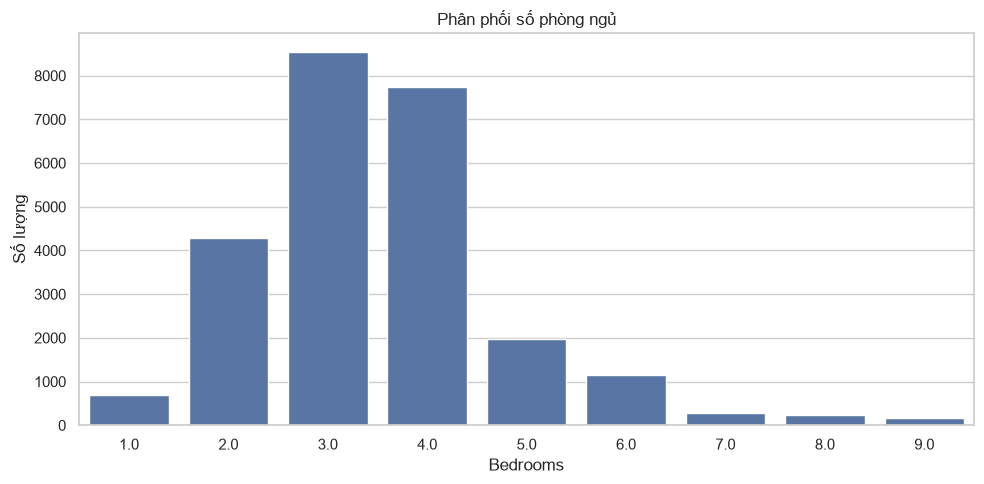

In [8]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Bedrooms"
)

plt.title("Phân phối số phòng ngủ")
plt.xlabel("Bedrooms")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()

## 6. Tiền xử lý dữ liệu

### Xử lý thuộc tính Address

`Address` chứa địa chỉ chi tiết và có thể có rất nhiều giá trị
khác nhau.

Nếu One-Hot Encoding toàn bộ địa chỉ sẽ tạo ra số lượng feature
rất lớn.

Do đó, trích xuất phần địa phương ở cuối địa chỉ và tạo biến
`Location`.

Sau đó sử dụng `Location` thay cho `Address`.

In [9]:
# ============================================================
# TẠO VÀ CHUẨN HÓA LOCATION
# ============================================================

# Lấy tỉnh/thành phố từ cuối Address
df["Location"] = (
    df["Address"]
    .fillna("Unknown")
    .astype(str)
    .str.split(",")
    .str[-1]
    .str.strip()
)

# Loại bỏ dấu "." ở cuối tên địa phương
df["Location"] = (
    df["Location"]
    .str.rstrip(".")
    .str.strip()
)

# Các giá trị không xác định được đưa về Other
df["Location"] = df["Location"].replace(
    ["", "Unknown", "nan"],
    "Other"
)

# Đếm số lượng từng Location
location_counts = df["Location"].value_counts()

# Gom Location có ít hơn 10 mẫu thành Other
rare_locations = location_counts[
    location_counts < 10
].index

df["Location"] = df["Location"].replace(
    rare_locations,
    "Other"
)

# Không sử dụng Address trực tiếp trong mô hình
df = df.drop(columns=["Address"])

# Kiểm tra kết quả
print("Số lượng Location:", df["Location"].nunique())

display(df["Location"].value_counts())

Số lượng Location: 38


Location
Hồ Chí Minh        11778
Hà Nội             10457
Bình Dương          1672
Đà Nẵng             1437
Đồng Nai             829
Hải Phòng            789
Khánh Hòa            743
Hưng Yên             405
Long An              339
Bà Rịa Vũng Tàu      240
Bắc Ninh             167
Bình Thuận           127
Lâm Đồng             118
Other                116
Cần Thơ              111
Quảng Ninh           110
Thanh Hóa            109
Kiên Giang            83
Đắk Lắk               77
Hà Nam                49
Bình Định             48
Quảng Nam             43
Hòa Bình              39
Phú Thọ               38
Vĩnh Phúc             33
Lào Cai               31
Thừa Thiên Huế        30
Nghệ An               28
Bắc Giang             26
Tiền Giang            24
Thái Bình             22
Thái Nguyên           20
Tây Ninh              19
Phú Yên               18
Ninh Thuận            17
Hà Tĩnh               13
Hải Dương             12
Quảng Trị             12
Name: count, dtype: int64

In [10]:
print(df.columns.tolist())

['Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price', 'Location']


## 7. Xác định Features và Target

`Price` là biến mục tiêu cần dự đoán.

Các thuộc tính còn lại được sử dụng làm biến đầu vào.

- `X`: Features.
- `y`: Target (`Price`).

In [11]:
X = df.drop(columns=["Price"])
y = df["Price"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (30229, 11)
Target: (30229,)


## 8. Phân loại các thuộc tính

Các thuộc tính số sẽ được:

- Điền giá trị thiếu bằng median.
- Chuẩn hóa bằng StandardScaler.

Các thuộc tính categorical sẽ được:

- Điền giá trị thiếu bằng giá trị xuất hiện nhiều nhất.
- Chuyển đổi bằng One-Hot Encoding.

In [12]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']

Categorical features:
['House direction', 'Balcony direction', 'Legal status', 'Furniture state', 'Location']


/var/folders/gt/shyrv8fj2b7d7_br935dyvg40000gn/T/ipykernel_15471/1263442432.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


## 9. Chia dữ liệu Train/Test

Dataset được chia thành:

- 80% Training: dùng để huấn luyện.
- 20% Testing: dùng để đánh giá.

Tập Test không được sử dụng trong quá trình huấn luyện.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (24183, 11)
Testing : (6046, 11)


## 10. Xây dựng Pipeline tiền xử lý

Đối với dữ liệu số:

Missing Value → Median → StandardScaler

Đối với dữ liệu categorical:

Missing Value → Most Frequent → One-Hot Encoding

Pipeline giúp đảm bảo quá trình xử lý dữ liệu khi huấn luyện
và khi triển khai trên Web là giống nhau.

In [14]:
# Pipeline cho dữ liệu số
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline cho dữ liệu categorical
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Kết hợp hai pipeline
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# 11. Xây dựng 5 mô hình Machine Learning

Để giải quyết bài toán dự đoán giá nhà, xây dựng 5 mô hình Regression:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. Support Vector Regression (SVR)

Tất cả mô hình sử dụng chung một Pipeline tiền xử lý dữ liệu.

In [15]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "SVR": SVR()
}

## 12. Huấn luyện 5 mô hình

Mỗi mô hình được kết hợp với Pipeline tiền xử lý
và huấn luyện trên cùng tập Training.

Sau đó sử dụng tập Testing để đánh giá hiệu quả.

In [16]:
trained_models = {}
predictions = {}

for name, model in models.items():

    print(f"Đang huấn luyện: {name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    predictions[name] = pipeline.predict(X_test)

print("\nHoàn thành!")

Đang huấn luyện: Linear Regression
Đang huấn luyện: Decision Tree
Đang huấn luyện: Random Forest
Đang huấn luyện: Gradient Boosting
Đang huấn luyện: SVR

Hoàn thành!


# 13. Đánh giá 5 mô hình

Các mô hình được đánh giá bằng 5 độ đo:

### MAE
Mean Absolute Error - sai số tuyệt đối trung bình.
Càng nhỏ càng tốt.

### MSE
Mean Squared Error - bình phương sai số trung bình.
Càng nhỏ càng tốt.

### RMSE
Root Mean Squared Error - căn bậc hai của MSE.
Càng nhỏ càng tốt.

### R²
R-squared - mức độ mô hình giải thích sự biến thiên của giá.
Càng lớn càng tốt.

### MAPE
Mean Absolute Percentage Error - sai số phần trăm tuyệt đối.
Càng nhỏ càng tốt.

In [17]:
results = []

for name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    # Price > 0 nên có thể tính MAPE
    mape = np.mean(
        np.abs((y_test - y_pred) / y_test)
    ) * 100

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2,MAPE (%)
0,Linear Regression,1.450579,3.285917,1.812710,0.326092,32.151258
1,Decision Tree,1.512591,4.305633,2.075002,0.116959,31.648219
2,Random Forest,1.238033,2.663805,1.632117,0.453681,26.676593
3,Gradient Boosting,1.310343,2.712905,1.647090,0.443611,28.991938
4,SVR,1.263444,2.630093,1.621756,0.460595,26.808097


## 14. So sánh kết quả

Bảng kết quả cho phép so sánh hiệu suất của 5 mô hình
trên cùng một tập Testing.

Mô hình tốt cần có:

- MAE thấp.
- MSE thấp.
- RMSE thấp.
- MAPE thấp.
- R² cao.

In [18]:
results_sorted = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

results_sorted.style.format({
    "MAE": "{:,.4f}",
    "MSE": "{:,.4f}",
    "RMSE": "{:,.4f}",
    "R2": "{:.4f}",
    "MAPE (%)": "{:.2f}%"
})

,Model,MAE,MSE,RMSE,R2,MAPE (%)
0,SVR,1.2634,2.6301,1.6218,0.4606,26.81%
1,Random Forest,1.2380,2.6638,1.6321,0.4537,26.68%
2,Gradient Boosting,1.3103,2.7129,1.6471,0.4436,28.99%
3,Linear Regression,1.4506,3.2859,1.8127,0.3261,32.15%
4,Decision Tree,1.5126,4.3056,2.0750,0.1170,31.65%


## 15. Trực quan hóa kết quả mô hình

Sử dụng R² và RMSE để trực quan hóa sự khác biệt
giữa 5 mô hình.

- R² càng cao càng tốt.
- RMSE càng thấp càng tốt.

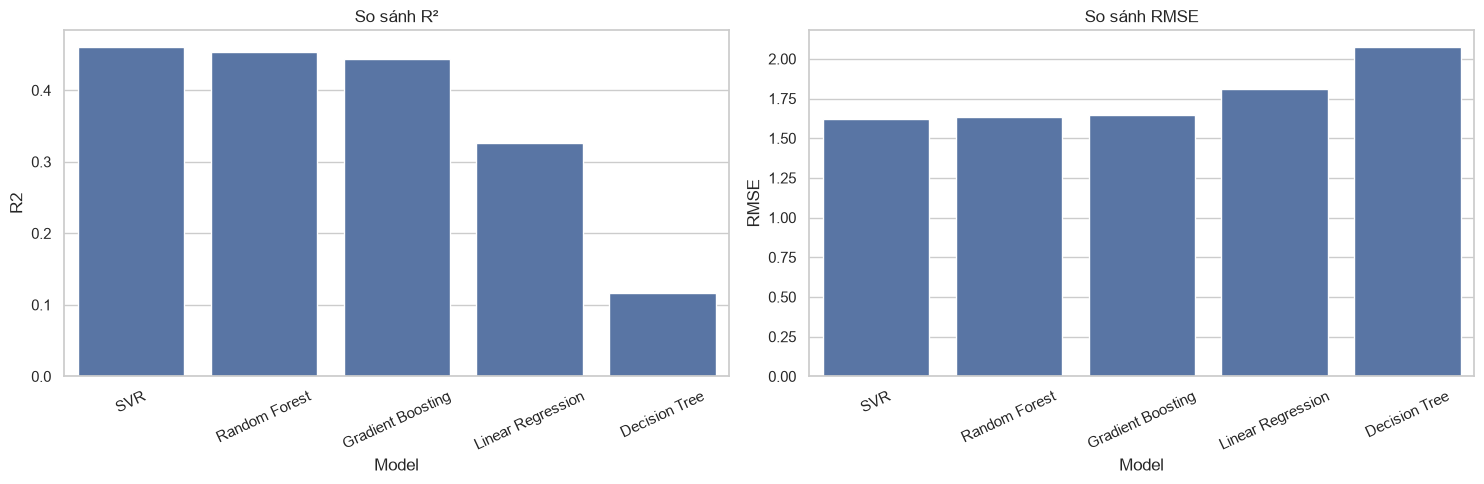

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R2
sns.barplot(
    data=results_sorted,
    x="Model",
    y="R2",
    ax=axes[0]
)

axes[0].set_title("So sánh R²")
axes[0].tick_params(axis="x", rotation=25)

# RMSE
sns.barplot(
    data=results_sorted,
    x="Model",
    y="RMSE",
    ax=axes[1]
)

axes[1].set_title("So sánh RMSE")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

# 16. Lựa chọn mô hình tốt nhất

Mô hình được lựa chọn dựa trên kết quả thực nghiệm.

Tiêu chí chính:

- R² cao.
- RMSE thấp.
- MAE thấp.
- MAPE thấp.

R² được sử dụng làm tiêu chí chính để xác định mô hình
có khả năng giải thích dữ liệu tốt nhất.

In [20]:
best_model_name = results_sorted.iloc[0]["Model"]

best_model = trained_models[best_model_name]

best_result = results_sorted.iloc[0]

print("================================")
print("      BEST MODEL")
print("================================")

print("Model:", best_model_name)
print(f"MAE : {best_result['MAE']:,.4f}")
print(f"MSE : {best_result['MSE']:,.4f}")
print(f"RMSE: {best_result['RMSE']:,.4f}")
print(f"R²  : {best_result['R2']:.4f}")
print(f"MAPE: {best_result['MAPE (%)']:.2f}%")

      BEST MODEL
Model: SVR
MAE : 1.2634
MSE : 2.6301
RMSE: 1.6218
R²  : 0.4606
MAPE: 26.81%


## 17. Actual vs Predicted

So sánh giá thực tế với giá dự đoán của mô hình tốt nhất.

Các điểm càng gần đường:

`Predicted = Actual`

thì mô hình càng có khả năng dự đoán chính xác.

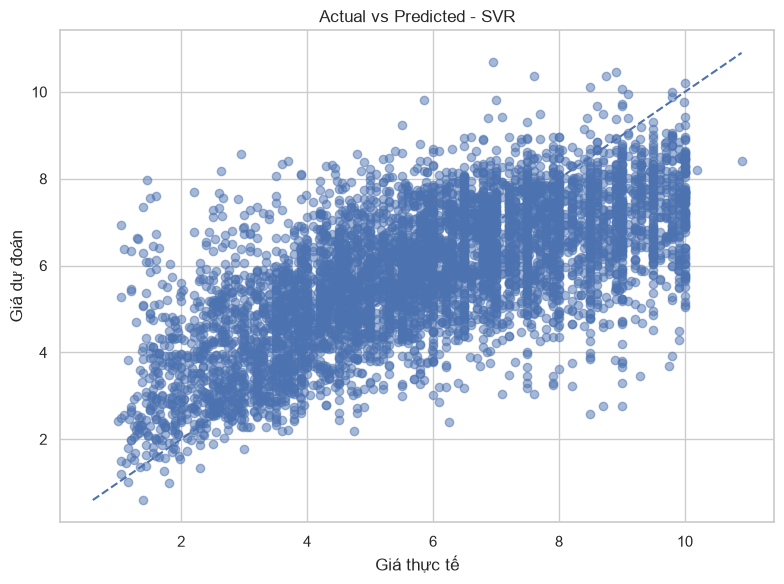

In [21]:
best_predictions = predictions[best_model_name]

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")

plt.title(
    f"Actual vs Predicted - {best_model_name}"
)

plt.tight_layout()
plt.show()

# 18. Lưu mô hình tốt nhất

Mô hình tốt nhất được lưu dưới dạng file `.pkl`.

Toàn bộ Pipeline được lưu, bao gồm:

- Xử lý missing value.
- StandardScaler.
- One-Hot Encoding.
- Machine Learning model.

File này sẽ được sử dụng bởi Web Application để dự đoán
giá nhà từ dữ liệu người dùng nhập vào.

In [22]:
import os

# Tạo thư mục models nếu chưa tồn tại
os.makedirs("../models", exist_ok=True)

# Lưu toàn bộ pipeline
model_path = "../models/best_model.pkl"

joblib.dump(
    best_model,
    model_path
)

print("Đã lưu model:", model_path)

Đã lưu model: ../models/best_model.pkl


## 19. Kiểm tra mô hình sau khi lưu

Load lại file model và thực hiện dự đoán thử
để đảm bảo mô hình có thể sử dụng độc lập.

In [23]:
loaded_model = joblib.load(
    "../models/best_model.pkl"
)

test_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print("5 giá trị dự đoán:")
print(test_prediction)

5 giá trị dự đoán:
[6.7432538  7.68904534 5.44632513 6.33171265 6.03559223]


## Kiểm tra mô hình tốt nhất bằng dữ liệu mới

Sử dụng một mẫu dữ liệu giả lập có cấu trúc giống dữ liệu
người dùng sẽ nhập trên website để kiểm tra Pipeline
có thể thực hiện dự đoán thành công hay không.

In [24]:
# ============================================================
# TEST BEST MODEL
# ============================================================

# Tạo một bất động sản mẫu
sample_house = pd.DataFrame([{

    "Area": 84,

    "Frontage": 6,

    "Access Road": 13,

    "House direction": "Đông - Bắc",

    "Balcony direction": "Đông - Bắc",

    "Floors": 5,

    "Bedrooms": 3,

    "Bathrooms": 2,

    "Legal status": "Have certificate",

    "Furniture state": "Full",

    "Location": "Hưng Yên"

}])


# Dự đoán
sample_prediction = best_model.predict(
    sample_house
)[0]


print("================================")
print("       TEST PREDICTION")
print("================================")

print(
    f"Giá nhà dự đoán: "
    f"{sample_prediction:.2f} tỷ VNĐ"
)

       TEST PREDICTION
Giá nhà dự đoán: 7.95 tỷ VNĐ


## Kiểm tra khả năng xử lý dữ liệu thiếu

Dataset thực tế chứa nhiều giá trị bị thiếu.

Do đó kiểm tra mô hình với trường hợp người dùng không
cung cấp đầy đủ thông tin để đảm bảo Pipeline có thể tự
xử lý missing values thông qua SimpleImputer.

In [25]:
# ============================================================
# TEST VỚI DỮ LIỆU THIẾU
# ============================================================

sample_missing = pd.DataFrame([{

    "Area": 84,

    "Frontage": np.nan,

    "Access Road": np.nan,

    "House direction": np.nan,

    "Balcony direction": np.nan,

    "Floors": 4,

    "Bedrooms": np.nan,

    "Bathrooms": np.nan,

    "Legal status": "Have certificate",

    "Furniture state": np.nan,

    "Location": "Hưng Yên"

}])


# Dự đoán
prediction_missing = best_model.predict(
    sample_missing
)[0]


print("================================")
print("   TEST MISSING DATA")
print("================================")

print(
    f"Giá nhà dự đoán: "
    f"{prediction_missing:.2f} tỷ VNĐ"
)

   TEST MISSING DATA
Giá nhà dự đoán: 8.50 tỷ VNĐ


In [26]:
print(type(best_model))
print(best_model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Area', 'Frontage',
                                                   'Access Road', 'Floors',
                                                   'Bedrooms', 'Bathrooms']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                            

## Kết luận lựa chọn mô hình

Sau khi thực nghiệm 5 mô hình học máy trên cùng tập dữ liệu
và đánh giá bằng 5 độ đo gồm MAE, MSE, RMSE, R² và MAPE,
có thể nhận thấy:

- SVR đạt R² cao nhất với giá trị 0.4606.
- SVR đạt RMSE thấp nhất với giá trị 1.6218.
- Random Forest đạt MAE và MAPE thấp hơn SVR một chút.
- Decision Tree có hiệu quả thấp nhất trong 5 mô hình.
- Linear Regression có khả năng giải thích dữ liệu thấp hơn
  so với SVR, Random Forest và Gradient Boosting.

Trong bài toán dự đoán giá nhà, R² và RMSE được sử dụng làm
tiêu chí chính để lựa chọn mô hình. SVR có R² cao nhất và
RMSE thấp nhất nên được lựa chọn làm mô hình triển khai trên
website.

=> Mô hình được lựa chọn: SVR.